In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Exploration: Load and visualize the data.

In [4]:
data=pd.read_csv('ex2data1.txt')

In [5]:
data.head()

,34.62365962451697,78.0246928153624,0
0,30.286711,43.894998,0
1,35.847409,72.902198,0
2,60.182599,86.308552,1
3,79.032736,75.344376,1
4,45.083277,56.316372,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   34.62365962451697  99 non-null     float64
 1   78.0246928153624   99 non-null     float64
 2   0                  99 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 2.4 KB


In [7]:
new_headers=['Exam_1','Exam_2',"Pass"]
data.columns=new_headers

In [8]:
data.head()

,Exam_1,Exam_2,Pass
0,30.286711,43.894998,0
1,35.847409,72.902198,0
2,60.182599,86.308552,1
3,79.032736,75.344376,1
4,45.083277,56.316372,0


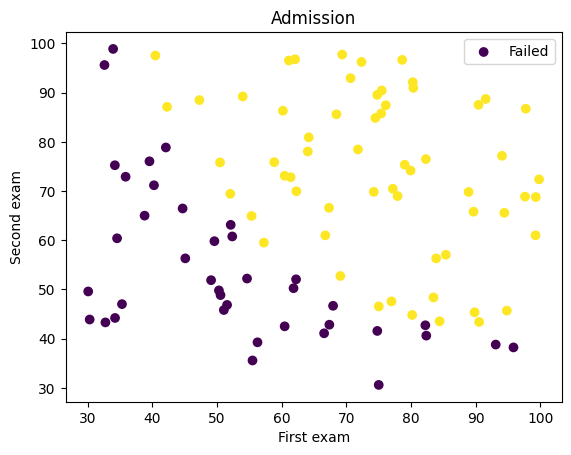

In [9]:
plt.scatter(data['Exam_1'], data['Exam_2'], c=data['Pass'], cmap='viridis')
plt.xlabel('First exam')
plt.ylabel('Second exam')
plt.title('Admission')
plt.legend(['Failed', 'Passed'])
plt.show()

# Applying Logistic Regression with scikit-learn:

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
x = data[['Exam_1', 'Exam_2']]
y = data['Pass']

# Split the data: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Create a pipeline for logistic regression
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

In [17]:
#Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression())])

# Making Predictions:

In [18]:
#Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

#Visualize the decision boundary
x_min, x_max = X_train['Exam_1'].min() - 1, X_train['Exam_1'].max() + 1
y_min, y_max = X_train['Exam_2'].min() - 1, X_train['Exam_2'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict the output for the entire grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Interpret the result of logistic regression and the accuracy of your model.

<ipython-input-19-47d82c30bdd9>:6: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test['Exam_1'], X_test['Exam_2'], c=y_test, marker='x', edgecolor='k', cmap=plt.cm.Paired, label='Testing')


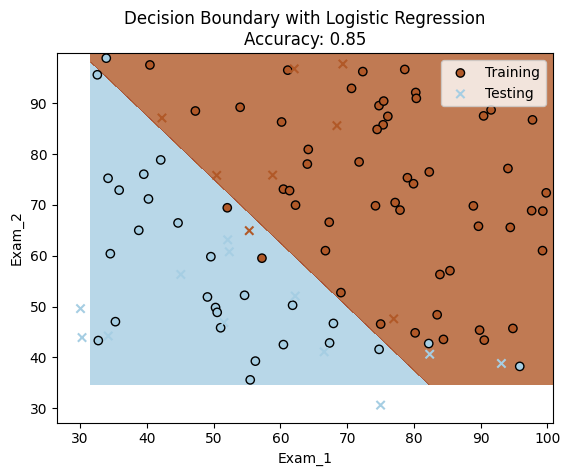

In [19]:
# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)

# Plot the training and testing points
plt.scatter(X_train['Exam_1'], X_train['Exam_2'], c=y_train, marker='o', edgecolor='k', cmap=plt.cm.Paired, label='Training')
plt.scatter(X_test['Exam_1'], X_test['Exam_2'], c=y_test, marker='x', edgecolor='k', cmap=plt.cm.Paired, label='Testing')

# Add labels, title, and legend
plt.title(f"Decision Boundary with Logistic Regression\nAccuracy: {accuracy:.2f}")
plt.xlabel('Exam_1')
plt.ylabel('Exam_2')
plt.legend()
plt.show()

# Conclusion

On this we can plot we can see, that our model worked pretty accurate (0.85) with some outliers on both, training and testing, models. Also I tried running this data with different separation and when I left 20% for testing instead of 30% it became more accurate.